# Results tour

The headline results of the current version, read straight from the CSVs in `results/`. Nothing is downloaded and no model is fit, so this runs in a few seconds.

Every CSV is written by `scripts/make_results.py` from cached model output; [`results/README.md`](../results/README.md) lists which file backs which number in the README. Notebooks 01–06 are v1's analysis, kept for history.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

RESULTS = next(p for p in (Path("results"), Path("..") / "results") if p.is_dir())  # repo root or notebooks/
read = lambda name: pl.read_csv(RESULTS / f"{name}.csv")
pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)

polars.config.Config

## 1. The 2023 leaderboard, with intervals

Δ is extra called strikes per shadow-zone pitch, against a reference catcher whose random effect is zero. Framing runs are Δ × shadow-zone pitches × 0.125. The intervals are 95% posterior intervals, conditional on the fitted baseline model.

27 of 102 catchers have intervals excluding zero


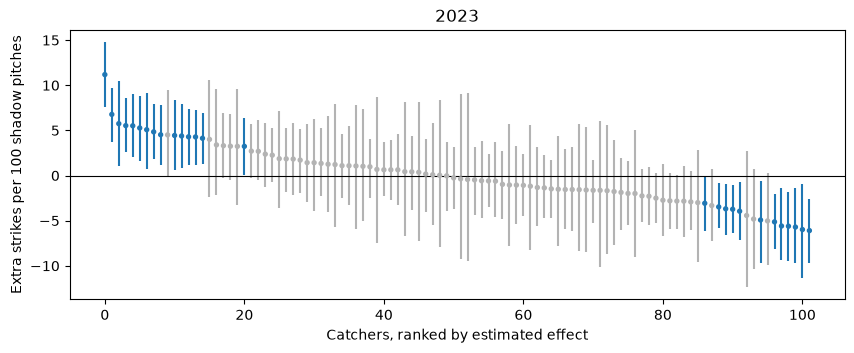

In [2]:
lb = read("leaderboard_2023_holdout").sort("delta", descending=True)
separated = (pl.col("delta_lo") > 0) | (pl.col("delta_hi") < 0)
print(f"{lb.filter(separated).height} of {lb.height} catchers have intervals excluding zero")

color = ["tab:blue" if s else "0.7" for s in lb.select(separated).to_series()]
x = range(lb.height)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.vlines(x, lb["delta_lo"] * 100, lb["delta_hi"] * 100, colors=color)
ax.scatter(x, lb["delta"] * 100, c=color, s=8, zorder=3)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="Catchers, ranked by estimated effect",
       ylabel="Extra strikes per 100 shadow pitches", title="2023")
plt.show()

Among the catchers Savant lists as qualified, ranked by framing runs, the top five and bottom three:

In [3]:
qualified = lb.filter(pl.col("savant_runs").is_not_null()).sort("runs", descending=True)
cols = ["name", "shadow_pitches", "runs", "runs_lo", "runs_hi", "savant_runs"]
pl.concat([qualified.head(5), qualified.tail(3)]).select(cols)

name,shadow_pitches,runs,runs_lo,runs_hi,savant_runs
str,i64,f64,f64,f64,f64
"""Hedges, Austin""",791,11.055,7.454,14.598,14.485
"""Alvarez, Francisco""",1088,9.209,5.103,13.119,13.946
"""Heim, Jonah""",1181,7.142,2.643,11.634,11.911
"""Bailey, Patrick""",965,6.669,3.136,10.343,16.963
"""Raleigh, Cal""",1180,6.308,1.777,10.625,6.348
"""Ruiz, Keibert""",1410,-6.583,-11.165,-1.854,-11.886
"""Realmuto, J.T.""",1445,-6.661,-11.913,-1.695,-14.428
"""Maldonado, Martín""",1154,-7.405,-11.695,-3.032,-15.663


## 2. How many catchers can be told apart

`share_pairs_resolved` is the share of catcher pairs where one is ahead with posterior probability above 0.95; `adjacent_p_median` is the median of that probability for neighbors in the ranking.

In [4]:
read("separability").select(
    "fit", "min_shadow_pitches", "n_catchers", "intervals_excluding_zero",
    "share_pairs_resolved", "adjacent_p_median",
)

fit,min_shadow_pitches,n_catchers,intervals_excluding_zero,share_pairs_resolved,adjacent_p_median
str,i64,i64,i64,f64,f64
"""2023_holdout""",0,102,27,0.273,0.515
"""2023_holdout""",500,49,20,0.470,0.542
"""2023_holdout""",1000,15,8,0.552,0.622
"""2021_2022_train""",0,148,34,0.257,0.511
"""2021_2022_train""",500,73,30,0.484,0.523
"""2021_2022_train""",1000,44,20,0.511,0.535
"""2024_holdout""",0,100,20,0.234,0.512
"""2024_holdout""",500,46,16,0.440,0.537
"""2024_holdout""",1000,18,6,0.438,0.579


## 3. Simulation: do the intervals cover the true effects?

Eight scenarios with known true effects, 100 replications each, with the baseline treated as known. `coverage_extreme` is coverage for the third of catchers with the largest absolute true effects.

In [5]:
sim = read("sim_coverage")
cov = sim.pivot(on="estimator", index="scenario", values="coverage").sort("residual_runs")
cov.join(sim.filter(pl.col("estimator") == "hierarchical")
            .select("scenario", hierarchical_extreme="coverage_extreme"), on="scenario")

scenario,hierarchical,residual_runs,hierarchical_extreme
str,f64,f64,f64
"""baseline""",0.947,0.920,0.890
"""battery""",0.940,0.784,0.874
"""heavy_tail""",0.944,0.915,0.878
"""location_mix""",0.945,0.775,0.879
"""location_shared""",0.955,0.907,0.907
"""omitted_covariate""",0.929,0.740,0.878
"""umpire_confound""",0.956,0.829,0.914
"""unequal""",0.948,0.917,0.889


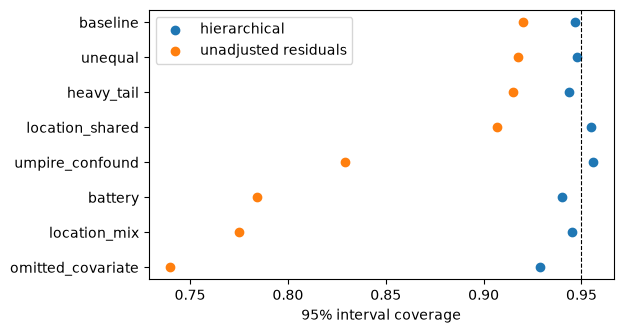

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
y = range(cov.height)
ax.scatter(cov["hierarchical"], y, label="hierarchical")
ax.scatter(cov["residual_runs"], y, label="unadjusted residuals")
ax.axvline(0.95, color="k", lw=0.8, ls="--")
ax.set_yticks(list(y), cov["scenario"].to_list())
ax.set(xlabel="95% interval coverage")
ax.legend(loc="upper left")
plt.show()

## 4. What the external check can and cannot see

Correlation with Savant's published framing runs, for both methods, with a paired catcher-bootstrap interval on the difference. The intervals include zero in every season but 2025. They treat the fitted catcher estimates as fixed, so they do not carry the uncertainty of the full two-stage pipeline.

In [7]:
read("vs_savant_by_season")

season,n_catchers,hierarchical,residual_runs,diff_hier_minus_resid,diff_ci_lo,diff_ci_hi,n_boot
i64,i64,f64,f64,f64,f64,f64,i64
2021,59,0.892,0.914,-0.021,-0.068,0.014,8000
2022,60,0.952,0.961,-0.009,-0.027,0.009,8000
2023,63,0.942,0.936,0.006,-0.016,0.036,8000
2024,58,0.942,0.917,0.025,-0.003,0.055,8000
2025,57,0.955,0.647,0.308,0.208,0.427,8000


The 2025 gap comes from the baseline model, fit on 2021–2022 and never refit, which overpredicts the strike rate by 2.6 points that season. The hierarchical model absorbs a season-wide shift in its intercept; the unadjusted residuals cannot.

In [8]:
read("baseline_transport").select(
    "data", "strike_rate_actual", "strike_rate_predicted", "log_loss", "log_loss_intercept_recal",
).with_columns(gap_points=(pl.col("strike_rate_predicted") - pl.col("strike_rate_actual")) * 100)

data,strike_rate_actual,strike_rate_predicted,log_loss,log_loss_intercept_recal,gap_points
str,f64,f64,f64,f64,f64
"""2021_2022_val""",0.337,0.339,0.171,0.171,0.162
"""2023""",0.336,0.343,0.169,0.169,0.768
"""2024""",0.336,0.343,0.170,0.169,0.644
"""2025""",0.332,0.358,0.169,0.163,2.569


Re-estimating the baseline's calibration within each season closes the 2025 gap. Below, the unadjusted residuals on the shadow zone are correlated with Savant three ways: with the baseline as is, with its intercept re-estimated on that season, and with intercept and slope re-estimated. Re-estimating the intercept alone brings 2025 back to 0.964, against the hierarchical model's 0.955; adding the slope changes almost nothing.

This is a post-hoc calibration diagnostic on the seasons themselves. It shows that the 0.647 comes from the stale baseline; it does not show which method measures catcher skill better.

In [9]:
(read("savant_decomposition")
 .filter(pl.col("pitches") == "shadow")
 .pivot(on="baseline", index="season", values="r_savant")
 .rename({"train_only": "as_is", "intercept": "intercept_refit", "intercept_slope": "intercept_and_slope_refit"}))

season,as_is,intercept_refit,intercept_and_slope_refit
i64,f64,f64,f64
2023,0.936,0.960,0.960
2024,0.917,0.957,0.956
2025,0.647,0.964,0.964


## 5. Umpire against catcher variation

τ is the standard deviation of each group's random effects on the logit scale. `p_umpire_gt_catcher` is the posterior probability that umpires vary more than catchers within that fit; `p_below_2023` compares 2024 and 2025 with 2023 using independent draws. The 2021 and 2022 single-season fits (0.88 and 0.41) are printed by `models/compare_engines.py` and are not in this file.

In [10]:
read("variance_components").select(
    "fit", "group", "tau_mean", "tau_eti_lo", "tau_eti_hi", "p_umpire_gt_catcher", "p_below_2023",
)

fit,group,tau_mean,tau_eti_lo,tau_eti_hi,p_umpire_gt_catcher,p_below_2023
str,str,f64,f64,f64,f64,f64
"""2023_holdout""","""catcher""",0.200,0.163,0.247,0.811,null
"""2023_holdout""","""umpire""",0.226,0.190,0.270,null,null
"""2023_holdout""","""pitcher""",0.202,0.162,0.245,null,null
"""2021_2022_train""","""catcher""",0.188,0.157,0.226,0.464,null
"""2021_2022_train""","""umpire""",0.186,0.159,0.219,null,null
"""2021_2022_train""","""pitcher""",0.182,0.159,0.206,null,null
"""2024_holdout""","""catcher""",0.183,0.147,0.225,0.916,0.719
"""2024_holdout""","""umpire""",0.223,0.187,0.265,null,0.552
"""2024_holdout""","""pitcher""",0.198,0.160,0.240,null,0.548


## Where to go next

- [METHODS.md](../METHODS.md): the estimand, identification, the simulation design, and where the numbers are weaker than they look.
- [ABS.md](../ABS.md): the 2026 postscript on the ABS challenge system.